In [1]:
from typing import List
import re

import numpy as np
from matplotlib import pyplot as plt
import matplotlib

# include the path to the parent directory

import sys
sys.path.append('../../')

from mfgpflow.data_loader import StellarMassFunctions

# set a random number seed to reproducibility
np.random.seed(0)

In [2]:
import numpy as np
from mfgpflow.sb28_smf_loader import SMFDataLoaderSB28, counts_uncertainty_stacked   # <- your class file
from mfgpflow.sb28_smf_loader import SB28Paths
# from smf_uncertainty import counts_uncertainty_stacked  # <- your uncertainty fn

In [3]:
basedir = "../../data/SB28/ming-feng/"
#  The SMFs are obtained from the stellar mass of the galaxy catalog, 
# with each binned into 13 bins in the range [108.9, 1011.4] M⊙ which Leja et al. (2020) aims at.
log10M = np.array([
    8.15,  8.45,  8.75,  9.05,  9.35,  9.65, 9.95, 10.25, 10.55, 10.85, 11.15, 11.45, 11.75,
], dtype=np.float32)
snap_numbers = 73, 90

B = len(log10M)  # number of bins

paths = SB28Paths(basedir)
# paths.basedir = basedir

loader = SMFDataLoaderSB28(
    paths,
    log10M_centers=log10M,
    snapshots=snap_numbers,
    bin_edges=None,
    Lbox_mpc_over_h=25.0,
    y_transform="anscombe",
    standardize_X=True,
    standardize_Y=False,
)

## Visualize the SB28


In [10]:
loader.sigma_A128.shape, loader.Y128.shape, loader.log10M.shape


((2048, 26), (2048, 26), (13,))

Text(0.5, 0.98, 'SMF with uncertainties (SB28, snap 73)')

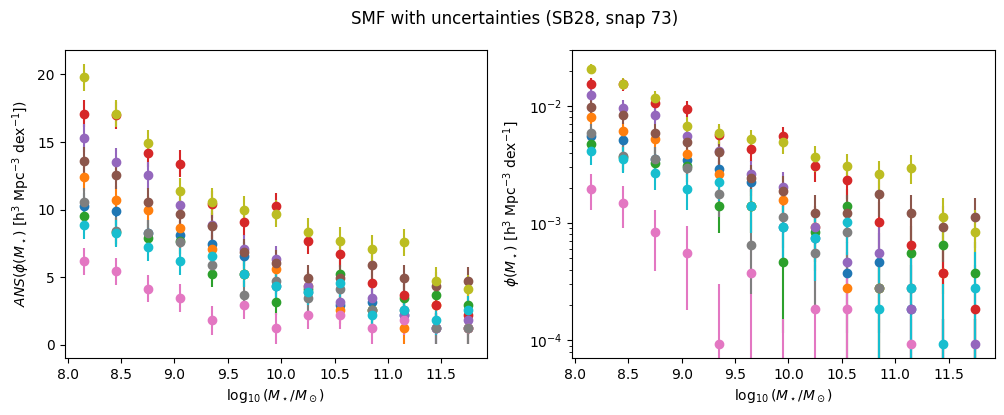

In [ ]:
# Snap 73
## Plotting multiple simulations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for sim_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    ax[0].errorbar(
        log10M,
        loader.Y256[sim_idx, :len(log10M)],
        yerr=loader.sigma_A256[sim_idx, :len(log10M)],
        fmt='o',
    )
    ax[1].errorbar(
        log10M,
        loader.PHI256[sim_idx, :len(log10M)],
        yerr=loader.sigma_phi256_total[sim_idx, :len(log10M)],
        fmt='o',
    )

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[0].set_ylabel(r"$ANS(\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$])")
ax[1].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[1].set_ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
ax[1].set_yscale('log')

fig.suptitle("SMF with uncertainties (SB28, snap 73)")
# plt.legend()

Text(0.5, 0.98, 'SMF with uncertainties (SB28, snap 90)')

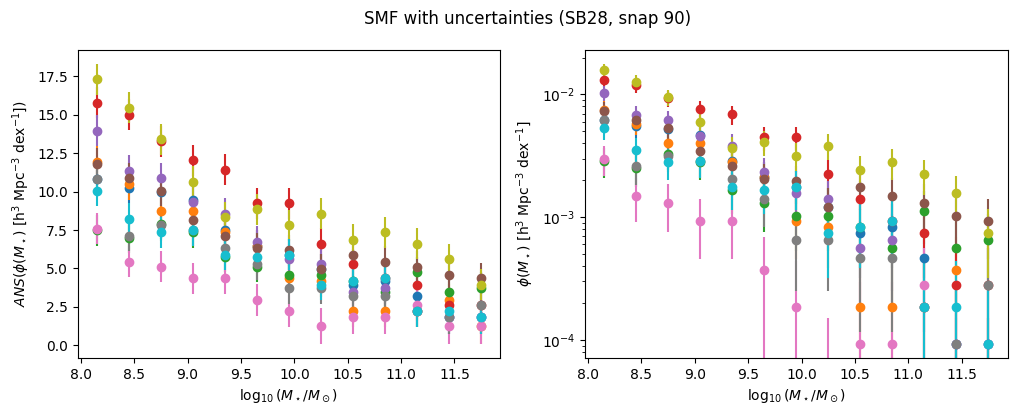

In [14]:
# Snap 90
## Plotting multiple simulations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for sim_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    ax[0].errorbar(
        log10M,
        loader.Y256[sim_idx, len(log10M):],
        yerr=loader.sigma_A256[sim_idx, len(log10M):],
        fmt='o',
    )
    ax[1].errorbar(
        log10M,
        loader.PHI256[sim_idx, len(log10M):],
        yerr=loader.sigma_phi256_total[sim_idx, len(log10M):],
        fmt='o',
    )

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[0].set_ylabel(r"$ANS(\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$])")
ax[1].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[1].set_ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
ax[1].set_yscale('log')

fig.suptitle("SMF with uncertainties (SB28, snap 90)")
# plt.legend()

## Input space

There are actually logFlag for some dimension, I should make sure the input are linear~

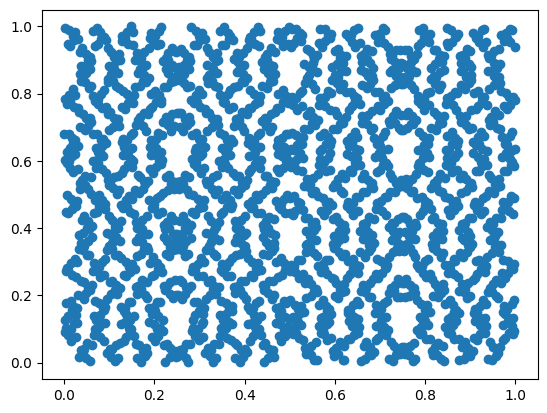

In [24]:
plt.scatter(loader.X128[:, 0], loader.X128[:, -1])

## Demo GP training:

128 -> 256 or 256 -> 512

In [29]:
from mfgpflow.linear_svgp import LatentMFCoregionalizationSVGP
import numpy as np
import gpflow
import tensorflow as tf
from sklearn.cluster import KMeans

In [27]:
loader.X512.shape, loader.Y512.shape, loader.X256.shape, loader.Y256.shape, loader.X128.shape, loader.Y128.shape

((128, 28), (32, 26), (2048, 28), (2048, 26), (2048, 28), (2048, 26))

In [51]:
import numpy as np

def suggest_L_from_Y(Y, thresh=0.95):
    """
    Y: (N, P) targets (stacked snapshots as columns).
    Returns smallest L explaining 'thresh' fraction of variance.
    """
    Yc = Y - Y.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Yc, full_matrices=False)  # S: singular values
    expl = (S**2) / np.sum(S**2)
    cum = np.cumsum(expl)
    L = int(np.searchsorted(cum, thresh) + 1)
    return L, expl, cum

# Example:
L_suggested, expl, cum = suggest_L_from_Y(loader.Y128)  # Y_train shape (N, 26)
print("Suggested L:", L_suggested)

Suggested L: 9


In [60]:
# 🔹 1️⃣ Load Data
# parameter dim: 28; output dim: 26
param_dim = loader.X512.shape[1]  # 28 input parameters
test_start = 1024 + 512
test_end = 1024 + 512 + 512
num_latents = 4     # Reduce latent GPs to match HF sparsity
num_inducing = 256  # Reduce inducing points to prevent overfitting

X_LF, Y_LF = loader.X128, loader.Y128 # LF Data (2048, 28) -> (2048, 26)
X_HF, Y_HF = loader.X256[:test_start], loader.Y256[:test_start, :] # HF Data (24, 28) → (24, 26)

# test data: shape (8, 28) -> (8, 26)
X_test_HF, Y_test_HF = loader.X256[test_start:test_end, :], loader.Y256[test_start:test_end, :]

# 🔹 2️⃣ Prepare Training Data
n_LF, n_HF = X_LF.shape[0], X_HF.shape[0]  # Number of points
output_dim = Y_LF.shape[1]

# ✅ Append fidelity indicators (0 for LF, 1 for HF)
X_LF_aug = np.hstack([X_LF, np.zeros((n_LF, 1))])  # LF data with fidelity=0
X_HF_aug = np.hstack([X_HF, np.ones((n_HF, 1))])   # HF data with fidelity=1

# ✅ Combine datasets
X_train = np.vstack([X_LF_aug, X_HF_aug])  # Shape: (2072, 29)
Y_train = np.vstack([Y_LF, Y_HF])  # Shape: (2072, 26)

# 🔹 3️⃣ Define Multi-Fidelity GP Model
# ✅ Define base kernels for LF and HF discrepancy
kernel_L = gpflow.kernels.Matern52(lengthscales=np.ones(param_dim), variance=1.0)
kernel_delta = gpflow.kernels.Matern52(lengthscales=np.ones(param_dim), variance=1.0)

# # ✅ Optimize Inducing Points using K-Means Clustering
# kmeans = KMeans(n_clusters=num_inducing, random_state=42).fit(X_train)
# Z_init = kmeans.cluster_centers_

# ✅ Initialize the Latent Multi-Fidelity Coregionalization SVGP model
mf_gp = LatentMFCoregionalizationSVGP(
    X_train, Y_train,
    kernel_L, kernel_delta,
    num_outputs=output_dim, num_latents=num_latents, num_inducing=num_inducing,
)

import time
start = time.time()
# 🔹 4️⃣ Train the Model with Adaptive Learning Rate
mf_gp.optimize(
    (X_train, Y_train),
    max_iters=2000,  # Reduce training iterations
    initial_lr=0.1,  # Lower learning rate for stability
    unfix_noise_after=500,  # Delay unfixing noise variance
    # decay_lr=True  # Enable learning rate decay
)

print(f"Training Time: {time.time() - start:.2f} seconds")

🔹 Iteration 0: ELBO = 2404158.7609935924
🔹 Iteration 100: ELBO = 170440.83365293895
🔹 Iteration 200: ELBO = 164278.6696447915
🔹 Iteration 300: ELBO = 151526.62744329413
🔹 Iteration 400: ELBO = 147078.58187113475
🔹 Iteration 500: ELBO = 143372.34217765526
🔹 Iteration 600: ELBO = 141918.1823325171
🔹 Iteration 700: ELBO = 142334.94418415814
🔹 Iteration 800: ELBO = 138772.14960575372
🔹 Iteration 900: ELBO = 137218.10634640208
🔹 Iteration 1000: ELBO = 138004.13786906344
🔹 Iteration 1100: ELBO = 136616.31765640937
🔹 Iteration 1200: ELBO = 135676.9786075017
🔹 Iteration 1300: ELBO = 135425.68795533865
🔹 Iteration 1400: ELBO = 135179.9542612978
🔹 Iteration 1500: ELBO = 135040.86339493454
🔹 Iteration 1600: ELBO = 134948.6682693177
🔹 Iteration 1700: ELBO = 134892.27240490715
🔹 Iteration 1800: ELBO = 134862.45163085568
🔹 Iteration 1900: ELBO = 134850.98010712734
Training Time: 329.78 seconds


Loss history

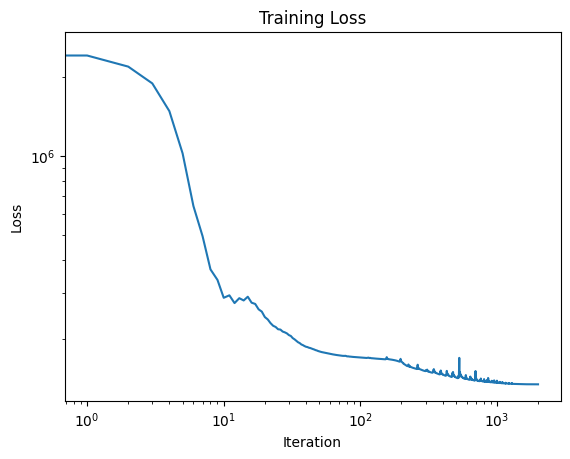

In [61]:
plt.plot(mf_gp.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale('log')
plt.xscale('log')
plt.title("Training Loss")
plt.show()

In [62]:

# 🔹 5️⃣ Make Predictions on HF Test Set
num_test_points = X_test_HF.shape[0]
X_test_HF_aug = np.hstack([X_test_HF, np.ones((num_test_points, 1))])  # Append fidelity indicators
mean_pred, var_pred = mf_gp.predict_f(X_test_HF_aug)

# 🔹 6️⃣ Compute Residuals
residuals = mean_pred.numpy() - Y_test_HF  # Shape: (10, 49)

# ✅ Print summary
print(f"🔍 Final Residuals: {residuals.mean():.4f} ± {residuals.std():.4f}")
print(f"✅ Model trained and predictions completed!")

# ✅ Check Learned W Matrix
print("🔍 Final Learned W Matrix:")
print(mf_gp.kernel.W.numpy())

# ✅ Check Noise Variance
print(f"🔍 Learned noise variance: {mf_gp.likelihood.variance.numpy()}")

# ✅ Evaluate Test Performance
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test_HF, mean_pred.numpy())
print(f"🔍 HF Prediction MSE: {mse:.4f}")

🔍 Final Residuals: 0.0081 ± 1.1611
✅ Model trained and predictions completed!
🔍 Final Learned W Matrix:
[[ 1.78636082 -0.45822734  0.68655139  1.05372894]
 [ 1.31672498 -0.28941357  0.90508184  1.08893739]
 [ 0.9025155  -0.07994748  1.06654535  1.06557321]
 [ 0.55208821  0.1920841   1.11911441  1.03451741]
 [ 0.29074805  0.45724387  1.07494983  0.98015192]
 [ 0.10058637  0.79633028  0.91977497  0.86019553]
 [ 0.02563811  1.06780842  0.66254099  0.74303787]
 [ 0.00877184  1.21304276  0.40072878  0.61742659]
 [ 0.02414866  1.29564597  0.1483977   0.50288569]
 [ 0.05756289  1.183984    0.00821653  0.39262118]
 [ 0.09866669  1.02666247 -0.09487746  0.29116459]
 [ 0.14057166  0.83005994 -0.13718817  0.18437298]
 [ 0.16671318  0.5893963  -0.11191631  0.11291043]
 [ 1.70800156 -0.40526327  0.68207244  0.74694253]
 [ 1.27382415 -0.25347417  0.90850062  0.78850784]
 [ 0.88664292 -0.03285852  1.05504946  0.79479854]
 [ 0.556522    0.20349836  1.1289323   0.7831352 ]
 [ 0.29839587  0.47066753  1.

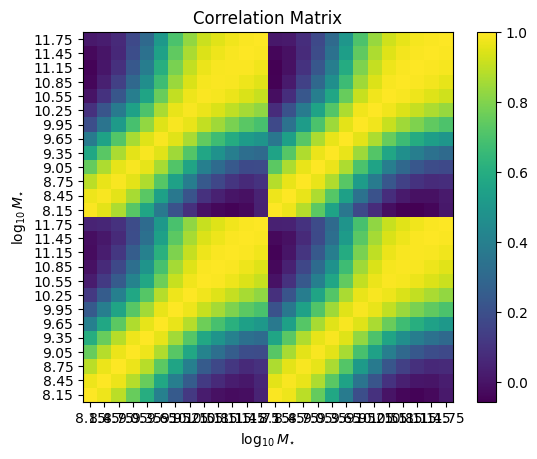

In [63]:
# Learned W Matrix
# plot the W matrix
# plt.imshow(mf_gp.kernel.W.numpy(), aspect="auto")
# plt.colorbar()
# plt.title("Learned W Matrix")
# plt.ylabel("Output Dimension")
# plt.xlabel("Latent Dimension")

K = mf_gp.kernel.W.numpy() @ mf_gp.kernel.W.numpy().T
# make it correlation matrix
D = np.diag(1/np.sqrt(np.diag(K)))
K = D @ K @ D

# Make the lower left corner to be origin of the plot
plt.imshow(K, cmap="viridis", origin="lower", )
plt.colorbar()
# I want the log mass bins to be ticks and labels
plt.xticks(range(2 * len(loader.log10M)), np.concatenate([loader.log10M, loader.log10M]))
plt.yticks(range(2 * len(loader.log10M)), np.concatenate([loader.log10M, loader.log10M]))
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\log_{10}M_{\star}$")
plt.title("Correlation Matrix")
plt.show()


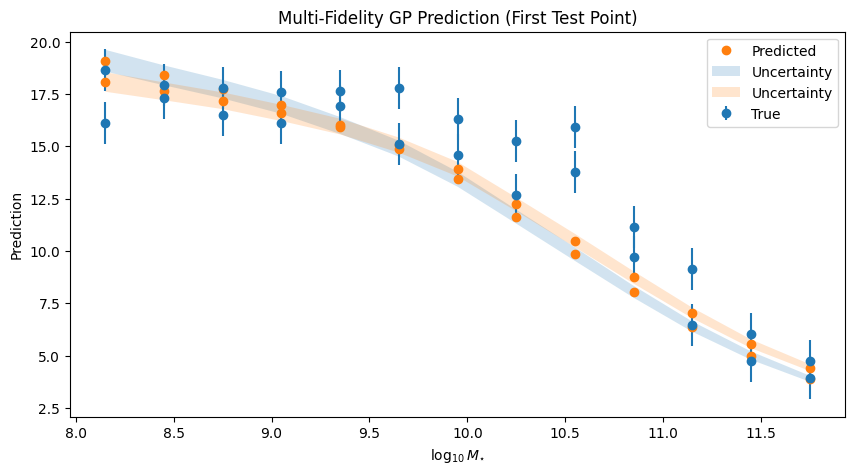

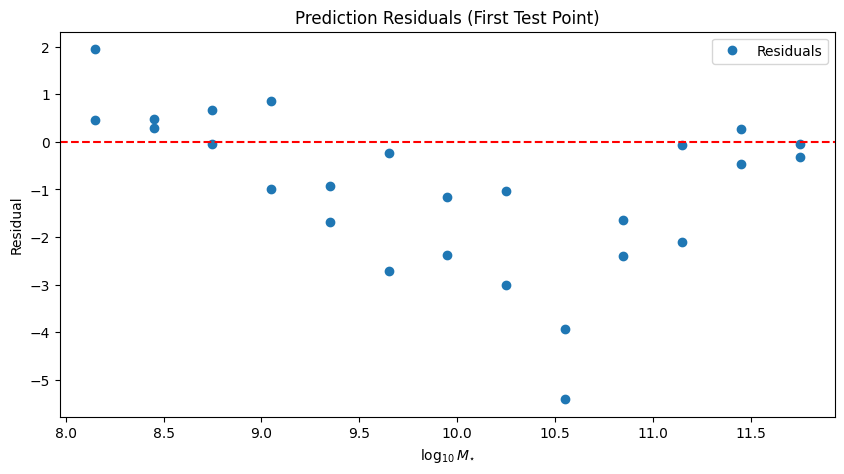

In [72]:
# Prediction
# 🔹 7️⃣ Plot Predictions vs Ground Truth
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.errorbar(np.concatenate([loader.log10M, loader.log10M]), Y_test_HF[0], yerr=loader.sigma_A256[test_start], fmt='o', label="True")
plt.plot(np.concatenate([loader.log10M, loader.log10M]), mean_pred.numpy()[0], ls="",marker="o", label="Predicted")
plt.fill_between(
    loader.log10M,
    (mean_pred.numpy()[0] - np.sqrt(var_pred.numpy()[0]))[:len(loader.log10M)],
    (mean_pred.numpy()[0] + np.sqrt(var_pred.numpy()[0]))[:len(loader.log10M)],
    alpha=0.2, label="Uncertainty"
)
plt.fill_between(
    loader.log10M,
    (mean_pred.numpy()[0] - np.sqrt(var_pred.numpy()[0]))[len(loader.log10M):],
    (mean_pred.numpy()[0] + np.sqrt(var_pred.numpy()[0]))[len(loader.log10M):],
    alpha=0.2, label="Uncertainty"
)

plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel("Prediction")
plt.legend()
plt.title("Multi-Fidelity GP Prediction (First Test Point)")
plt.show()

# 🔹 8️⃣ Residual Plot
plt.figure(figsize=(10, 5))
plt.plot(np.concatenate([loader.log10M, loader.log10M]), residuals[0], marker="o", ls="", label="Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel("Residual")
plt.legend()
plt.title("Prediction Residuals (First Test Point)")
plt.show()

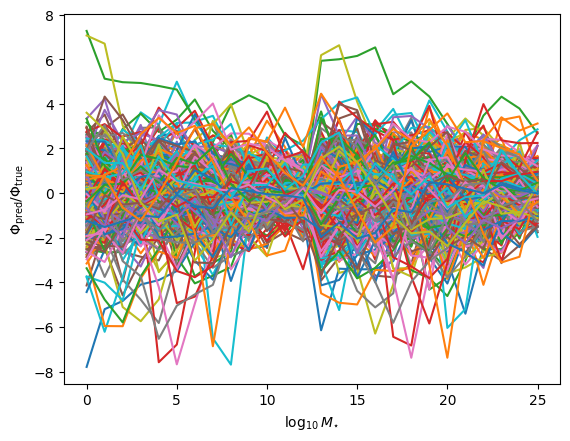

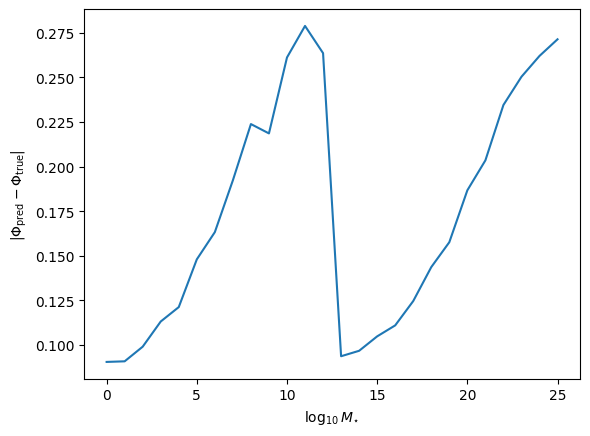

In [80]:
# Mode transformation
mode_linear = 10**(mean_pred - np.std(var_pred) * (np.log(10)))

# Correct variance transformation
sigma2_linear = (10**(2 * mean_pred)) * np.exp(np.std(var_pred) * (np.log(10)**2)) * (np.exp(np.std(var_pred) * (np.log(10)**2)) - 1)

# plt.plot(loader.log10M, (mean_pred - Y_test_HF).numpy().T);
plt.plot((mean_pred - Y_test_HF).numpy().T);
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\Phi_{\mathrm{pred}}/\Phi_{\mathrm{true}}$")
plt.show()
# absolute error
relative_error = np.abs(mean_pred / Y_test_HF - 1)
# plt.plot(loader.log10M, relative_error.mean(axis=0));
# plt.fill_between(loader.log10M, relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
plt.plot(relative_error.mean(axis=0));
# plt.fill_between(relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
# plt.ylim(0, 0.5)
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$|\Phi_{\mathrm{pred}}-\Phi_{\mathrm{true}}|$")
plt.show()